## Install the necessary packages

In [ ]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

## Import the libraries

In [32]:
# Import modules
import os
import pandas as pd
import seaborn as sns

from matplotlib import pyplot as plt

## Import data

In [33]:
# Define filename and path
filename = os.path.join('data', 'insurance-data.csv')

# Read the CSV file
df = pd.read_csv(filename)

In [34]:
# Display the top 5 rows
df.head()

,age,gender,bmi,children,smoker,region,charges,insuranceclaim
0,NaN,0.0,27.900,0,1,3,16884.92400,1
1,18.0,NaN,33.770,1,0,2,1725.55230,1
2,28.0,1.0,33.000,3,0,2,4449.46200,0
3,33.0,1.0,22.705,0,0,1,21984.47061,0
4,32.0,1.0,28.880,0,0,1,3866.85520,1


In [35]:
# Display the last 5 rows
df.tail()

,age,gender,bmi,children,smoker,region,charges,insuranceclaim
1333,50.0,1.0,30.97,3,0,1,10600.5483,0
1334,18.0,0.0,31.92,0,0,0,2205.9808,1
1335,18.0,0.0,36.85,0,0,2,1629.8335,1
1336,21.0,0.0,25.80,0,0,3,2007.9450,0
1337,61.0,0.0,29.07,0,1,1,29141.3603,1


In [36]:
# Show the total number of rows and columns
df.shape

(1338, 8)

In [8]:
# Get dataframe summary
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             1337 non-null   float64
 1   gender          1337 non-null   float64
 2   bmi             1338 non-null   float64
 3   children        1338 non-null   int64  
 4   smoker          1338 non-null   int64  
 5   region          1338 non-null   int64  
 6   charges         1338 non-null   float64
 7   insuranceclaim  1338 non-null   int64  
dtypes: float64(4), int64(4)
memory usage: 83.8 KB


In [37]:
# Describe dataframe (numerical columns only)
df.describe()

,age,gender,bmi,children,smoker,region,charges,insuranceclaim
count,1337.000000,1337.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.222139,0.504862,30.663397,1.094918,0.204783,1.515695,13270.422265,0.585202
std,14.044333,0.500163,6.098187,1.205493,0.403694,1.104885,12110.011237,0.492871
min,18.000000,0.000000,15.960000,0.000000,0.000000,0.000000,1121.873900,0.000000
25%,27.000000,0.000000,26.296250,0.000000,0.000000,1.000000,4740.287150,0.000000
50%,39.000000,1.000000,30.400000,1.000000,0.000000,2.000000,9382.033000,1.000000
75%,51.000000,1.000000,34.693750,2.000000,0.000000,2.000000,16639.912515,1.000000
max,64.000000,1.000000,53.130000,5.000000,1.000000,3.000000,63770.428010,1.000000


## Handle missing values

In [38]:
# Check for missing values
df.isna().sum()

age               1
gender            1
bmi               0
children          0
smoker            0
region            0
charges           0
insuranceclaim    0
dtype: int64

In [39]:
# We will drop the rows containing missing values
df.dropna(inplace=True)

In [40]:
# Re-check for missing values
df.isna().sum()

age               0
gender            0
bmi               0
children          0
smoker            0
region            0
charges           0
insuranceclaim    0
dtype: int64

## Handle duplicates

In [41]:
# Find duplicates (By default keep='first')
df[df.duplicated()]

,age,gender,bmi,children,smoker,region,charges,insuranceclaim
581,19.0,1.0,30.59,0,0,1,1639.5631,1


In [42]:
# Drop duplicates
df.drop_duplicates(inplace=True)

In [43]:
# Re-check for duplicates
df[df.duplicated()]

,age,gender,bmi,children,smoker,region,charges,insuranceclaim


## Visualize data

### 1. Bar Plot / Count Plot — Frequency of Categorical Variables

In [16]:
df['smoker'].value_counts()

smoker
0    1062
1     273
Name: count, dtype: int64

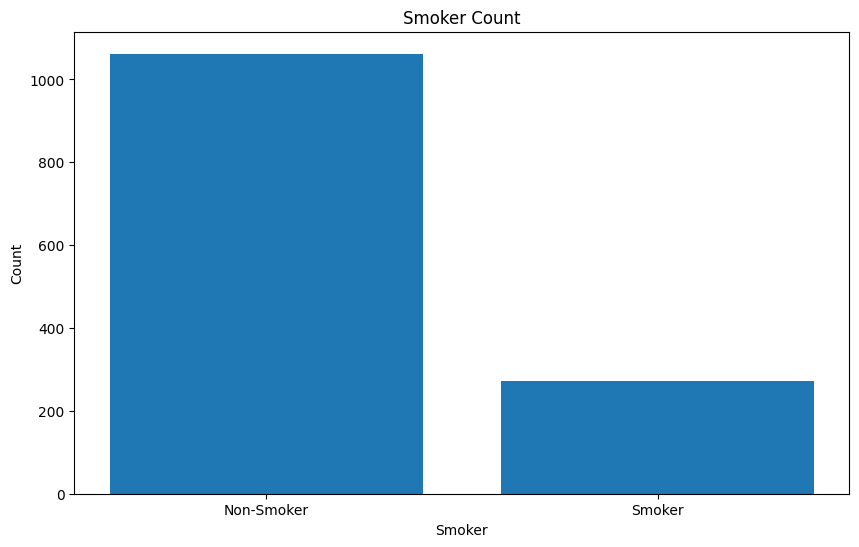

In [45]:
# Count occurrences of each smoker category
smoker_counts = df['smoker'].value_counts().sort_index()

# Create the figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the bar chart
ax.bar(smoker_counts.index.astype(str), smoker_counts.values)

# Set title and axis labels
ax.set_title('Smoker Count')
ax.set_xlabel('Smoker')
ax.set_ylabel('Count')

# Set custom tick labels
ax.set_xticks([0, 1])
ax.set_xticklabels(['Non-Smoker', 'Smoker'])

# Show the plot
plt.show()

In [47]:
df['gender'].value_counts()

gender
1.0    674
0.0    661
Name: count, dtype: int64

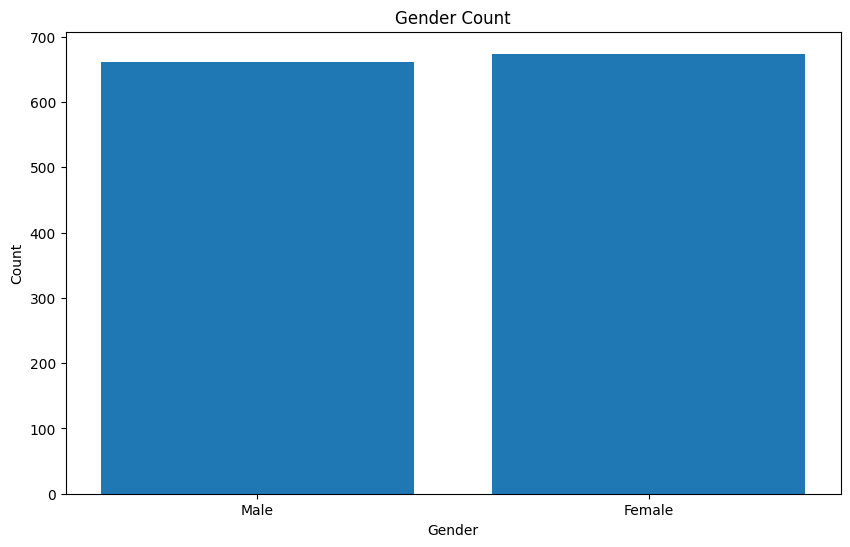

In [49]:
# Count occurrences of each gender
gender_counts = df['gender'].value_counts().sort_index()

# Create the figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the bar chart
ax.bar(gender_counts.index.astype(str), gender_counts.values)

# Set title and axis labels
ax.set_title('Gender Count')
ax.set_xlabel('Gender')
ax.set_ylabel('Count')

# Set custom tick labels
ax.set_xticks([0, 1])
ax.set_xticklabels(['Male', 'Female'])

# Show the plot
plt.show()

In [51]:
df['region'].value_counts()

region
2    363
1    324
0    324
3    324
Name: count, dtype: int64

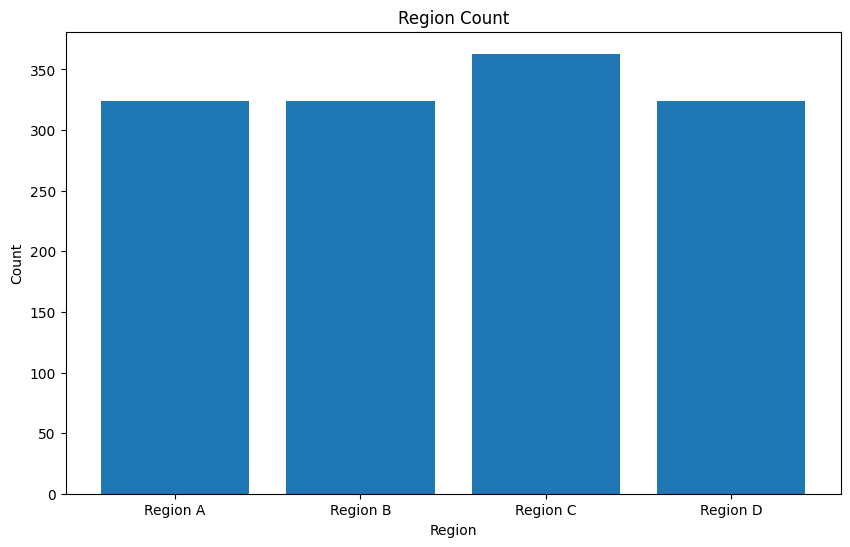

In [53]:
# Count occurrences of each region
region_counts = df['region'].value_counts().sort_index()

# Create the figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the bar chart
ax.bar(region_counts.index.astype(str), region_counts.values)

# Set title and axis labels
ax.set_title('Region Count')
ax.set_xlabel('Region')
ax.set_ylabel('Count')

# Set custom tick labels
ax.set_xticks([0, 1, 2, 3])
ax.set_xticklabels(['Region A', 'Region B', 'Region C', 'Region D'])

# Show the plot
plt.show()

In [54]:
df['insuranceclaim'].value_counts()

insuranceclaim
1    780
0    555
Name: count, dtype: int64

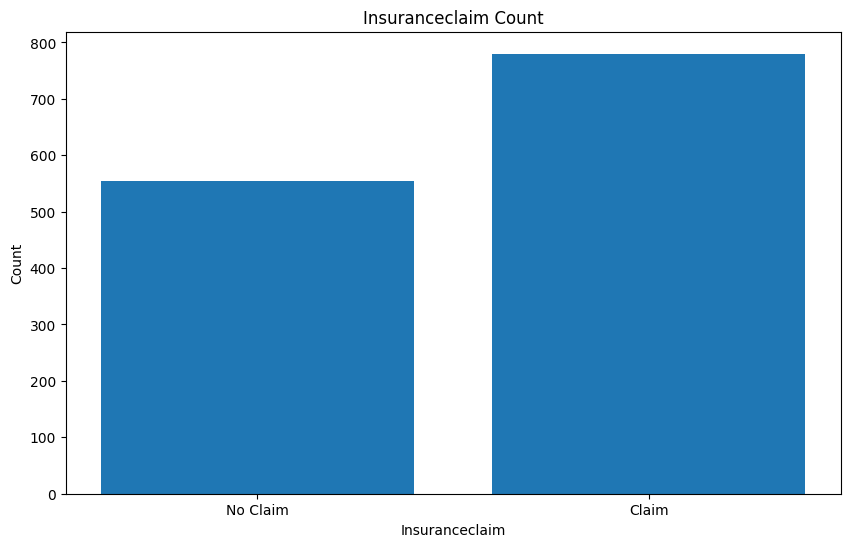

In [56]:
# Count occurrences of each insuranceclaim
insuranceclaim_counts = df['insuranceclaim'].value_counts().sort_index()

# Create the figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the bar chart
ax.bar(insuranceclaim_counts.index.astype(str), insuranceclaim_counts.values)

# Set title and axis labels
ax.set_title('Insuranceclaim Count')
ax.set_xlabel('Insuranceclaim')
ax.set_ylabel('Count')

# Set custom tick labels
ax.set_xticks([0, 1])
ax.set_xticklabels(['No Claim', 'Claim'])

# Show the plot
plt.show()

### 2. Histogram - Distribution of Numeric Variables

### 2.1. Age Distribution (histogram)

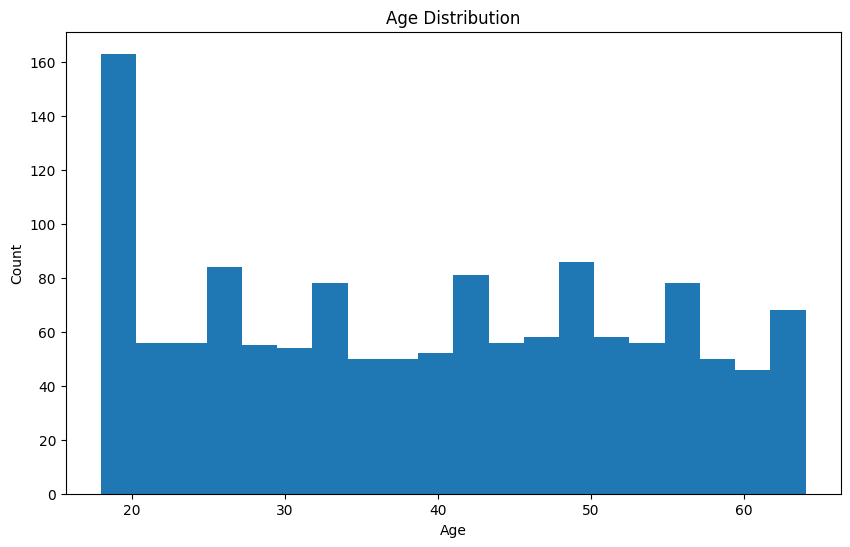

In [57]:
# Create a figure and a set of axes
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the data on the axes
ax.hist(df['age'], bins=20)

ax.set_title('Age Distribution')

# Set the label for the x-axis
ax.set_xlabel("Age")

# Set the label for the y-axis
ax.set_ylabel("Count")

# Display the plot
plt.show()

In [62]:
# How bar width is calculated
print(df["age"].max())
print(df["age"].min())

bin_range = (df["age"].max() - df["age"].min()) / 20
print(bin_range)

# Bin 1 = 18 + 2.3 = 20.3 -> [18, 20.3]

64.0
18.0
2.3


### 2.2. BMI Distribution (histogram)

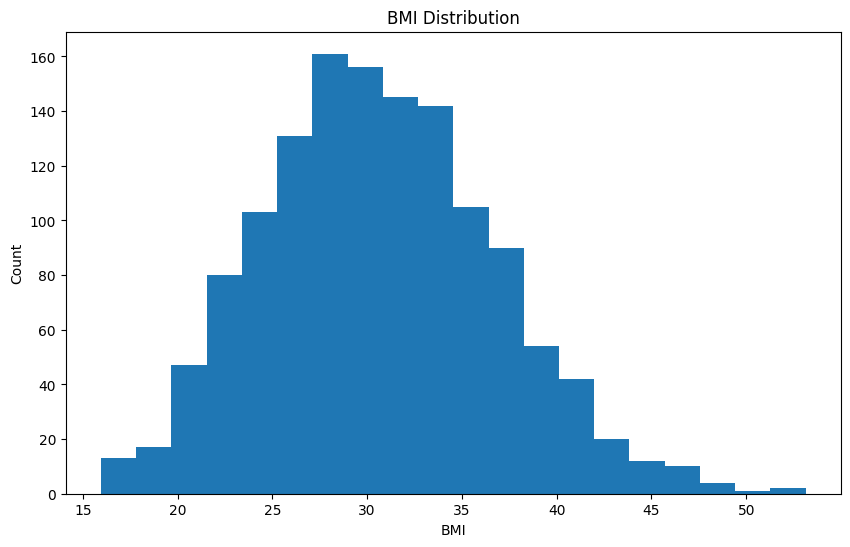

In [63]:
# Create a figure and a set of axes
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the data on the axes
ax.hist(df['bmi'], bins=20)

ax.set_title('BMI Distribution')

# Set the label for the x-axis
ax.set_xlabel("BMI")

# Set the label for the y-axis
ax.set_ylabel("Count")

# Display the plot
plt.show()

### 2.3. Charges Distribution (histogram)

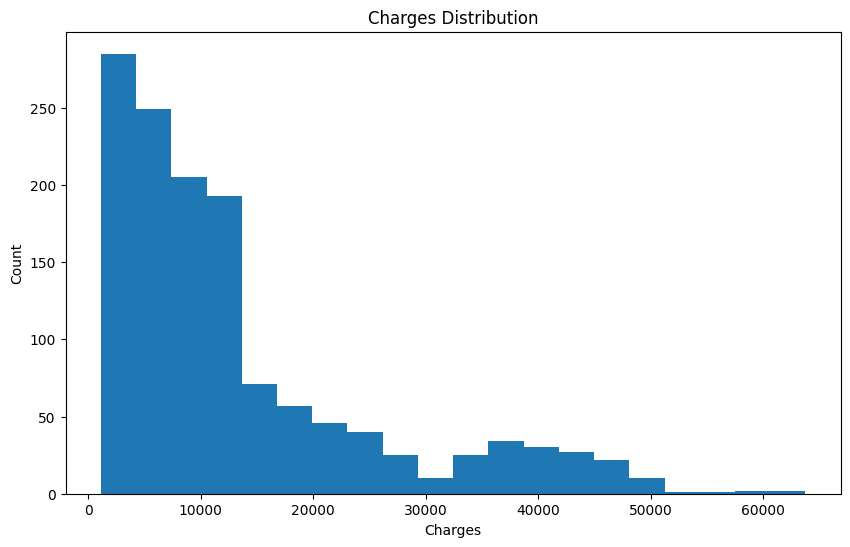

In [64]:
# Create a figure and a set of axes
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the data on the axes
ax.hist(df['charges'], bins=20)

ax.set_title('Charges Distribution')

# Set the label for the x-axis
ax.set_xlabel("Charges")

# Set the label for the y-axis
ax.set_ylabel("Count")

# Display the plot
plt.show()

### 3. Boxplot - Detect outliers / Compare groups

#### 3.1. BMI by Insurance Claim (Boxplot)

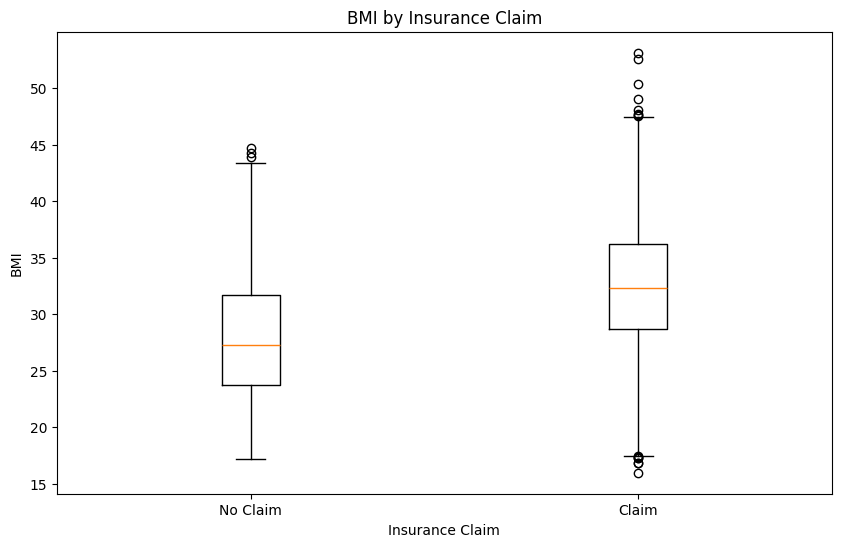

In [65]:
# Group BMI values by insurance claim status
grouped_data = [df[df['insuranceclaim'] == 0]['bmi'],
                df[df['insuranceclaim'] == 1]['bmi']]

# Create the boxplot
fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot(grouped_data)

# Set titles and labels
ax.set_title('BMI by Insurance Claim')
ax.set_xlabel("Insurance Claim")
ax.set_ylabel("BMI")

# Set custom x-tick labels
ax.set_xticklabels(['No Claim', 'Claim'])

# Show the plot
plt.show()

#### 3.2. Charges by Smoker (Boxplot)

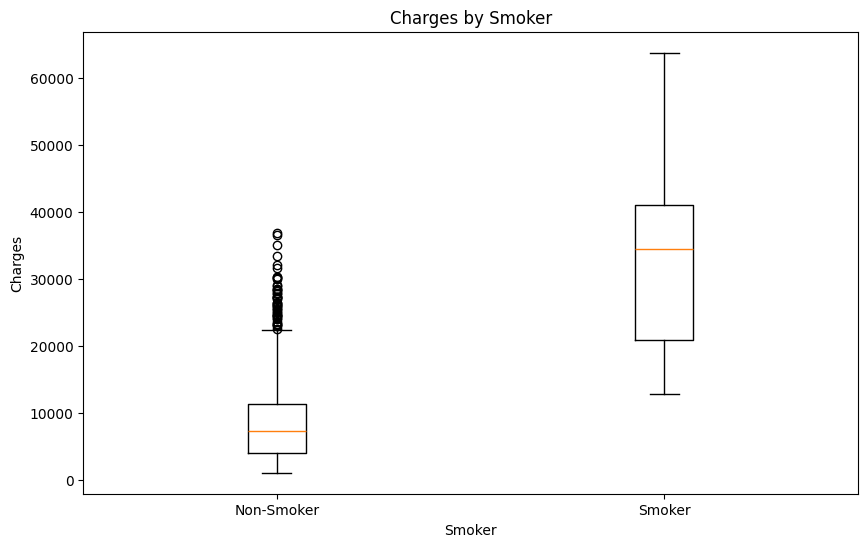

In [66]:
# Group charges by smoker status (0 = non-smoker, 1 = smoker)
grouped_data = [df[df['smoker'] == 0]['charges'],
                df[df['smoker'] == 1]['charges']]

# Create the boxplot
fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot(grouped_data)

# Set titles and labels
ax.set_title('Charges by Smoker')
ax.set_xlabel("Smoker")
ax.set_ylabel("Charges")

# Set custom x-tick labels
ax.set_xticklabels(['Non-Smoker', 'Smoker'])

# Show the plot
plt.show()

### 4. Pairplot / Scatter Matrix — Relationships between numerical features

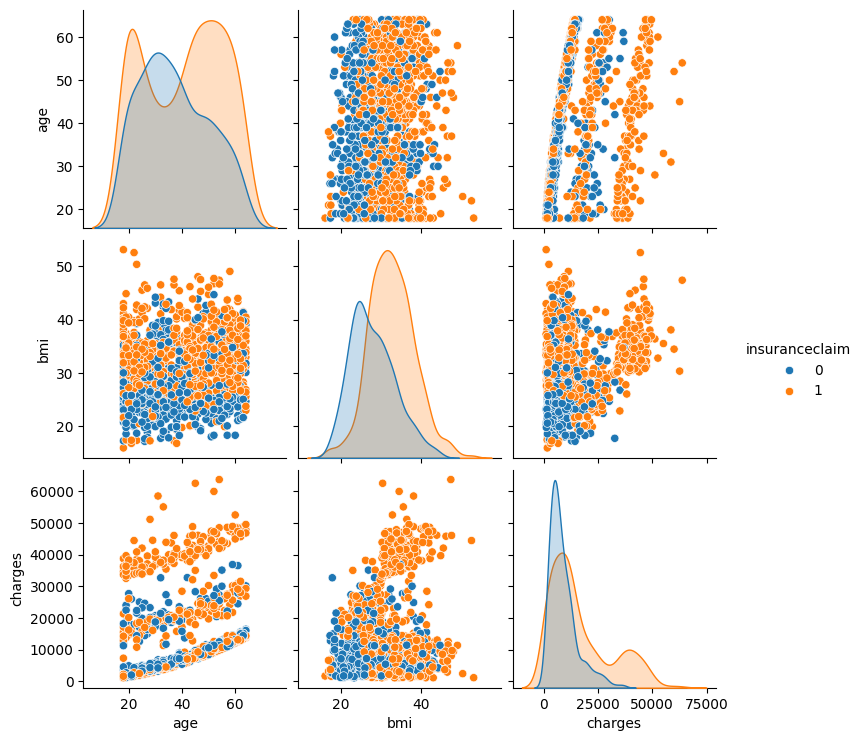

In [68]:
sns.pairplot(df, hue='insuranceclaim', vars=['age', 'bmi', 'charges'])
plt.show()

### 5. Heatmap — Correlation Between Numeric Variables

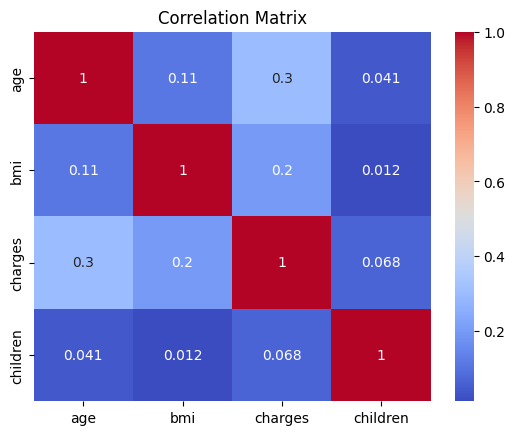

In [27]:
corr = df[['age', 'bmi', 'charges', 'children']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

### 6. Stacked Bar Plot — Comparing Binary Categories

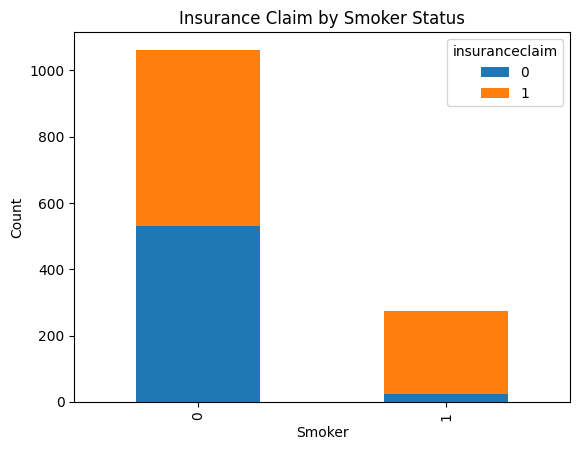

In [ ]:
cross_tab = pd.crosstab(df['smoker'], df['insuranceclaim'])
cross_tab.plot(kind='bar', stacked=True)

plt.title('Insurance Claim by Smoker Status')
plt.xlabel('Smoker')
plt.ylabel('Count')
plt.show()

### 7. Scatterplot of bmi vs charges colored by smoker

#### 7.1. BMI vs Charges by Smoking Status and Insurance Claim (Scatter)

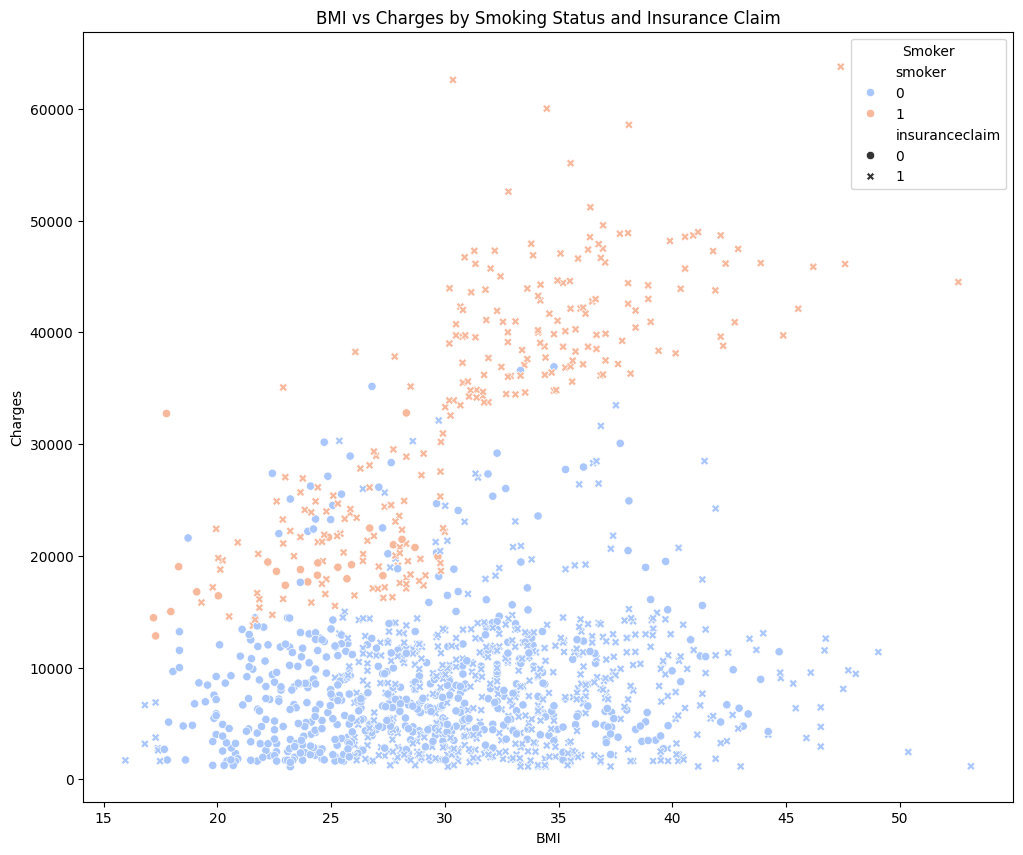

In [69]:
plt.figure(figsize=(12, 10))

sns.scatterplot(
    data=df,
    x='bmi',
    y='charges',
    hue='smoker',           # Color points by smoker status
    style='insuranceclaim', # Different marker shapes for claims
    palette='coolwarm'
)

plt.title('BMI vs Charges by Smoking Status and Insurance Claim')
plt.xlabel('BMI')
plt.ylabel('Charges')
plt.legend(title='Smoker')
plt.show()
